# Network Anomaly Detection

**Importing Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import itertools
from scipy.spatial.distance import cdist, pdist
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import train_test_split
from sklearn.metrics.cluster import contingency_matrix
from sklearn.decomposition import PCA
from sklearn.cluster import SpectralClustering, KMeans, kmeans_plusplus
from sklearn.neighbors import NearestNeighbors
from sklearn import preprocessing

plt.rcParams['figure.figsize'] = [10, 6]



**Utility Functions**

In [2]:
def nth_max(X, n):
    return np.partition(X.flatten(), -n)[-n]

In [3]:
def np_value_counts(ndarray):
    unique, counts = np.unique(ndarray, return_counts=True)
    return np.asarray((unique, counts)).T

## 1. Download Datset and Understand the Format

For this assignment, we will use the ”KDD Cup 1999” dataset, which is a widely used benchmark dataset for network anomaly detection. This dataset contains network traffic data collected from a simulated environment, including features such as protocol type, service, source and destination IP addresses, source and destination ports, and attack types. The data is available at the following [link](https://kdd.ics.uci.edu/databases/kddcup99/kddcup99.html). You will use the `kddcup.data.gz` for training and `corrected.gz` for testing. Analyze the dataset and preprocess the dataset to be ready for clustering. ”Change the categorical features to numerical”

In [4]:
with open('data/kddcup.names') as file:
    lines = [line.rstrip() for line in file]
columns = [line.split(":")[0] for line in lines[1:]]
columns.append('label')

In [5]:
presaved_files = os.path.isfile('train.gz') and os.path.isfile('train10.gz') and os.path.isfile('test.gz')
presaved_files

True

In [6]:
if presaved_files:
    train = pd.read_csv('train.gz', compression='gzip')
    train10 = pd.read_csv('train10.gz', compression='gzip')
    test = pd.read_csv('test.gz', compression='gzip')

In [7]:
if not presaved_files:
    train = pd.read_csv('data/kddcup.data.gz', compression='gzip', names=columns)
train

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,215,45076,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
1,0,162,4528,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
2,0,236,1228,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
3,0,233,2032,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
4,0,239,486,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4898426,0,212,2288,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
4898427,0,219,236,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
4898428,0,218,3610,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
4898429,0,219,1234,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False


In [8]:
if not presaved_files:
    train10 = pd.read_csv('data/kddcup.data_10_percent.gz', compression='gzip', names=columns)
train10

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,181,5450,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
1,0,239,486,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
2,0,235,1337,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
3,0,219,1337,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
4,0,217,2032,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494016,0,310,1881,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
494017,0,282,2286,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
494018,0,203,1200,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
494019,0,291,1200,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False


In [9]:
if not presaved_files:
    test = pd.read_csv('data/corrected.gz', compression='gzip', names=columns)
test

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,105,146,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
1,0,105,146,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
2,0,105,146,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
3,0,105,146,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
4,0,105,146,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311024,0,105,147,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
311025,0,105,147,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
311026,0,105,147,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
311027,0,105,147,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False


**One-Hot Encoding Categorical Columns**

In [10]:
def one_hot_encode_df(df1, df2, df3, columns_to_encode):
    dataframes = [df1, df2, df3]

    # Concatenate the DataFrames vertically
    concatenated_df = pd.concat(dataframes)

    # Perform one-hot encoding on the concatenated DataFrame
    encoded_df = pd.get_dummies(concatenated_df, columns=columns_to_encode)

    # Split the encoded DataFrame back into the original three DataFrames
    df1_encoded = encoded_df[:len(df1)]
    df2_encoded = encoded_df[len(df1):len(df1)+len(df2)]
    df3_encoded = encoded_df[len(df1)+len(df2):]

    return df1_encoded, df2_encoded, df3_encoded

In [11]:
if not presaved_files:
    train, train10, test = one_hot_encode_df(train, train10, test, ['protocol_type', 'service', 'flag'])

**Label encode labels**

In [12]:
if not presaved_files:
    le = preprocessing.LabelEncoder()
    le.fit(pd.concat([train['label'], test['label']], axis=0))
    le_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

    train.replace({'label': le_mapping}, inplace=True)
    train10.replace({'label': le_mapping}, inplace=True)
    test.replace({'label': le_mapping}, inplace=True)

**Save Processed Data for Later Runs**

In [13]:
train.iloc[:-1]

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,215,45076,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
1,0,162,4528,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
2,0,236,1228,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
3,0,233,2032,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
4,0,239,486,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4898425,0,219,244,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
4898426,0,212,2288,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
4898427,0,219,236,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
4898428,0,218,3610,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False


In [14]:
if not presaved_files:
    train.to_csv("train.gz", index=False, compression="gzip")
    train10.to_csv("train10.gz", index=False, compression="gzip")
    test.to_csv("test.gz", index=False, compression="gzip")
    
    presaved_files = True

**Dropping the label column**

In [15]:
train_label = train.loc[:, 'label']
train.drop(['label'], axis=1, inplace=True)

In [16]:
train10_label = train10.loc[:, 'label']
train10.drop(['label'], axis=1, inplace=True)

In [17]:
test_label = test.loc[:, 'label']
test.drop(['label'], axis=1, inplace=True)

**Dataset Analysis**

In [18]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898431 entries, 0 to 4898430
Columns: 123 entries, duration to flag_SH
dtypes: bool(85), float64(15), int64(23)
memory usage: 1.8 GB


In [19]:
train10.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494021 entries, 0 to 494020
Columns: 123 entries, duration to flag_SH
dtypes: bool(85), float64(15), int64(23)
memory usage: 183.3 MB


In [20]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311029 entries, 0 to 311028
Columns: 123 entries, duration to flag_SH
dtypes: bool(85), float64(15), int64(23)
memory usage: 115.4 MB


In [21]:
train.nunique()

duration           9883
src_bytes          7195
dst_bytes         21493
land                  2
wrong_fragment        3
                  ...  
flag_S1               2
flag_S2               2
flag_S3               2
flag_SF               2
flag_SH               2
Length: 123, dtype: int64

In [22]:
train10.nunique()

duration           2495
src_bytes          3300
dst_bytes         10725
land                  2
wrong_fragment        3
                  ...  
flag_S1               2
flag_S2               2
flag_S3               2
flag_SF               2
flag_SH               2
Length: 123, dtype: int64

In [23]:
test.nunique()

duration           745
src_bytes         2504
dst_bytes         9202
land                 2
wrong_fragment       3
                  ... 
flag_S1              2
flag_S2              2
flag_S3              2
flag_SF              2
flag_SH              2
Length: 123, dtype: int64

**Removing `num_outbound_cmds` column from dataset as it has only one value**

In [24]:
train.drop(columns=['num_outbound_cmds'], inplace=True)

In [25]:
train10.drop(columns=['num_outbound_cmds'], inplace=True)

In [26]:
test.drop(columns=['num_outbound_cmds'], inplace=True)

**Converting to NumPy arrays**

In [27]:
x_train = train.to_numpy().astype('float32')
y_train = train_label.to_numpy().astype('uint8')

x_train10 = train10.to_numpy().astype('float32')
y_train10 = train10_label.to_numpy().astype('uint8')

x_test = test.to_numpy().astype('float32')
y_test = test_label.to_numpy().astype('uint8')

**Running PCA on dataset to reduce dimensionality**

In [28]:
pca = PCA()
pca.fit(x_train)

# Calculate the number of components based on the desired variance ratio
explained_variance_ratio_cumsum = pca.explained_variance_ratio_.cumsum()
n_components = len(explained_variance_ratio_cumsum[explained_variance_ratio_cumsum < 0.9999]) + 1
n_components

2

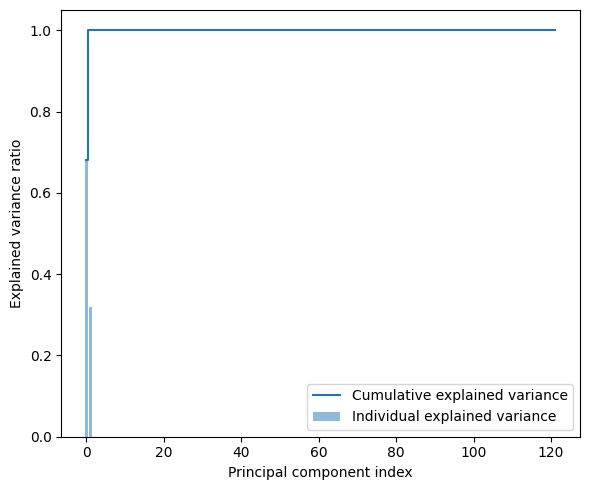

In [29]:
# Determine explained variance using explained_variance_ration_ attribute
exp_var_pca = pca.explained_variance_ratio_

# Cumulative sum of eigenvalues; This will be used to create step plot
# for visualizing the variance explained by each principal component.
cum_sum_eigenvalues = np.cumsum(exp_var_pca)

# Create the visualization plot
plt.figure(figsize=(6,5))
plt.bar(range(0, len(exp_var_pca)), exp_var_pca, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(0, len(cum_sum_eigenvalues)), cum_sum_eigenvalues, where='mid',label='Cumulative explained variance')

plt.xlabel('Principal component index')
plt.ylabel('Explained variance ratio')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [30]:
x_train = pca.transform(x_train)[:, :n_components]

In [31]:
x_train10 = pca.transform(x_train10)[:, :n_components]

In [32]:
x_test = pca.transform(x_test)[:, :n_components]

**Finalized Dataset**

In [33]:
x_train

array([[-1.6060293e+03,  4.3982875e+04],
       [-1.6715609e+03,  3.4348931e+03],
       [-1.5985808e+03,  1.3487048e+02],
       ...,
       [-1.6158447e+03,  2.5168760e+03],
       [-1.6155790e+03,  1.4087573e+02],
       [-1.6156211e+03,  4.8757324e+00]], dtype=float32)

In [34]:
y_train

array([16, 16, 16, ..., 16, 16, 16], dtype=uint8)

In [35]:
x_train10

array([[-1652.276   ,  4356.887   ],
       [-1595.8102  ,  -607.1304  ],
       [-1599.5471  ,   243.87073 ],
       ...,
       [-1631.5895  ,   106.880615],
       [-1543.5896  ,   106.853516],
       [-1615.579   ,   140.87573 ]], dtype=float32)

In [36]:
y_train10

array([16, 16, 16, ..., 16, 16, 16], dtype=uint8)

In [37]:
x_test

array([[-1729.9153 ,  -947.08905],
       [-1729.9153 ,  -947.08905],
       [-1729.9153 ,  -947.08905],
       ...,
       [-1729.915  ,  -946.08905],
       [-1729.915  ,  -946.08905],
       [-1729.915  ,  -946.08905]], dtype=float32)

In [38]:
y_test

array([16, 16, 16, ..., 16, 16, 16], dtype=uint8)

## 2. Clustering Using K-Means (Your implementation)

We will use K-Means to cluster the network traffic data and identify anomalies. Every data traffic is a feature vector of 41 dimension. We will use this feature representation to do the clustering.

• We will change the K of the K-means algorithm between {7, 15, 23, 31, 45} clusters. You will produce different clusters.

In [39]:
def k_means_clustering(X, k, epsilon=1e-6, num_iters=100):
    # Initialize k centroids using k-means++
    centroids, _ = kmeans_plusplus(X, n_clusters=k)
    
    old_centroids = np.copy(centroids)
    for t in range(num_iters):
        clusters = [set() for i in range(k)]
        
        # Cluster Assignment Step
        labels = np.argmin(np.linalg.norm(X[:, np.newaxis] - centroids, axis=2), axis=1)
    
        # Centroid Update Step
        for i in range(k):
            clusters[i] = np.where(labels==i)[0]
            if len(clusters[i]) == 0:
                centroids[i] = None
            else:
                centroids[i] = np.mean(X[clusters[i]], axis=0)

        if np.linalg.norm(centroids - old_centroids) <= epsilon:
            labels = np.argmin(np.linalg.norm(X[:, np.newaxis] - centroids, axis=2), axis=1)
            return labels, centroids
        else:
            old_centroids = np.copy(centroids)
    
    labels = np.argmin(np.linalg.norm(X[:, np.newaxis] - centroids, axis=2), axis=1)
    return labels, centroids

In [40]:
def k_means_test(x_test, centroids):
    return np.argmin(np.linalg.norm(x_test[:, np.newaxis] - centroids, axis=2), axis=1)

In [41]:
results = dict()
for k in [7, 15, 23, 31, 45]:
    print(f"@ k = {k}")
    labels, centroids = k_means_clustering(x_train10, k)
    
    results[k] = dict()
    results[k]['labels'] = labels
    results[k]['centroids'] = centroids
    results[k]['y_pred'] = k_means_test(x_test, centroids)

@ k = 7
@ k = 15
@ k = 23
@ k = 31
@ k = 45


In [42]:
results

{7: {'labels': array([0, 0, 0, ..., 0, 0, 0], dtype=int64),
  'centroids': array([[-9.3154846e+02, -5.4285785e+02],
         [ 6.9337370e+08, -2.1538522e+05],
         [ 5.1323920e+06, -2.6797070e+03],
         [-1.7772548e+02,  5.0085970e+06],
         [ 2.2017505e+06, -1.7740861e+03],
         [-7.7215839e+02,  1.6349184e+06],
         [ 7.7767446e+03,  3.9134419e+05]], dtype=float32),
  'y_pred': array([0, 0, 0, ..., 0, 0, 0], dtype=int64)},
 15: {'labels': array([0, 0, 0, ..., 0, 0, 0], dtype=int64),
  'centroids': array([[-1.1916377e+03, -9.2347595e+02],
         [ 6.9337370e+08, -2.1538522e+05],
         [ 5.1323920e+06, -2.6797070e+03],
         [-2.4319576e+02,  5.1492880e+06],
         [ 2.2017505e+06, -1.7740861e+03],
         [-3.9720853e+02,  2.4649650e+06],
         [-1.0279668e+03,  9.7311156e+05],
         [-1.2839755e+03,  2.3660256e+05],
         [ 3.4603674e+02,  3.8830675e+06],
         [ 5.3974176e+04,  6.6989497e+03],
         [-8.6603741e+02,  1.5140226e+06],
    

## 3. Normalized Cut (Your implementation)

Here, we will use Normalized cut algorithm to cluster the network traffic data and identify anomalies. For this experiments we need to decrease the size of the dataset for it to run successfully.

• Set the random seed across all experiments to 42.

• Split the training dataset used using train test split in sklearn, and take
only 0.5% of the data in the new training set. Be sure you set stratify = True.

• Apply Normalized Cut algorithm to the preprocessed data to cluster the data into 23 clusters.

• Rerun the experiments on K-Means when K = 23.

• Compare the results of K-Means and Normalized Cut clustering in terms of the number of detected anomalies and their characteristics.

In [43]:
def normalised_cut(X, k_clusters, sim_measure='rbf'):
    # Find Similarity Matrix A using specified similarity measure
    if sim_measure == 'rbf':
        g_optimal = 1 / np.mean(pdist(X))
        A = rbf_kernel(X, gamma=g_optimal)
    elif sim_measure == 'knn':
        k_optimal = int(np.round(np.sqrt(X.shape[0])))
        knn = NearestNeighbors(n_neighbors=151).fit(X)
        A = knn.kneighbors_graph(X).toarray()
    
    # Find Degree Matrix Δ
    delta = np.diag(A.sum(axis=1))
    
    # Calculate the Laplacian Matrix L
    L = delta - A
    
    # Calculate the normalized asymmetric Matrix B
    B = np.dot(np.linalg.inv(delta), L)
    
    # Extract eigenvalues and eigenvectors of B
    lambdas, U = np.linalg.eig(B)
    indices = lambdas.argsort()
    lambdas = np.real(lambdas[indices])
    U = np.real(U[:, indices])
    
    # Run K-Means on smallest k eigenvectors
    kmeans = KMeans(n_clusters=k_clusters, n_init=100)
    kmeans.fit(U[:, 1:k_clusters+1])
    
    return kmeans.labels_

In [44]:
x_train2, _, y_train2, _ = train_test_split(x_train, y_train, train_size=0.0025, random_state=42, stratify=y_train)

In [45]:
x_train2.shape

(12246, 2)

In [46]:
y_train2.shape

(12246,)

In [47]:
nc_labels = normalised_cut(x_train2, 23)
nc_labels

array([0, 0, 0, ..., 0, 0, 0])

In [48]:
from sklearn.cluster import SpectralClustering

# Number of clusters
k_clusters = 23

# Perform Spectral Clustering using nearest neighbors affinity
spectral_model = SpectralClustering(
    n_clusters=k_clusters,
    affinity='nearest_neighbors',  # Uses KNN internally
    n_neighbors=23,                # Number of neighbors for KNN graph
    assign_labels='kmeans',       # Use KMeans for final clustering
    random_state=42,              # For reproducibility
    n_init=10                     # Number of KMeans initializations
)

# Fit the model and get labels
nc_labels_knn = spectral_model.fit_predict(x_train2)

# Print or return the labels
print(nc_labels_knn)


C:\Users\dalpa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


[ 0  0  5 ... 10 21  0]


**K-Means Clustering vs. Normalized Cut**

In [49]:
np_value_counts(results[23]['labels'])

array([[     0, 174130],
       [     1,      1],
       [     2,     59],
       [     3,     16],
       [     4,     24],
       [     5,      3],
       [     6,    312],
       [     7,     13],
       [     8,   2314],
       [     9,      2],
       [    10,     43],
       [    11,      2],
       [    12,      8],
       [    13,     10],
       [    14,   5819],
       [    15,   1715],
       [    16, 293210],
       [    17,      9],
       [    18,     21],
       [    19,  16222],
       [    20,      3],
       [    21,     66],
       [    22,     19]], dtype=int64)

In [50]:
np_value_counts(nc_labels)

array([[    0, 12194],
       [    1,     2],
       [    2,     3],
       [    3,     3],
       [    4,     1],
       [    5,     2],
       [    6,     1],
       [    7,     2],
       [    8,     4],
       [    9,     2],
       [   10,     4],
       [   11,     1],
       [   12,     2],
       [   13,     5],
       [   14,     1],
       [   15,     2],
       [   16,     4],
       [   17,     3],
       [   18,     4],
       [   19,     1],
       [   20,     1],
       [   21,     1],
       [   22,     3]], dtype=int64)

In [51]:
np_value_counts(nc_labels_knn)

array([[   0, 6765],
       [   1,  909],
       [   2,   79],
       [   3,  107],
       [   4,  289],
       [   5, 1476],
       [   6,  239],
       [   7,  145],
       [   8,  129],
       [   9,   27],
       [  10,  183],
       [  11,   66],
       [  12,  251],
       [  13,  154],
       [  14,  257],
       [  15,  166],
       [  16,  124],
       [  17,   45],
       [  18,   98],
       [  19,   83],
       [  20,  179],
       [  21,  283],
       [  22,  192]], dtype=int64)

## 4. Evaluation

We will evaluate models based on their ability to detect network anomalies accurately. You will be required to use the following metrics to evaluate the quality of their models:

• Precision

• Recall

• F1 score

• Conditional Entropy

**Running K-Means on `x_train2` for evaluation purposes**

In [52]:
km_results = dict()
for k in [7, 15, 23, 31, 45]:
    print(f"@ k = {k}")
    labels, centroids = k_means_clustering(x_train2, k)
    
    km_results[k] = dict()
    km_results[k]['labels'] = labels
    km_results[k]['centroids'] = centroids
    km_results[k]['y_pred'] = k_means_test(x_test, centroids)

@ k = 7
@ k = 15
@ k = 23
@ k = 31
@ k = 45


### Precision

In [53]:
def precision_per_cluster(y_true, y_pred):
    cont_mat = contingency_matrix(y_true, y_pred).T
    return np.max(cont_mat, axis=1) / np.sum(cont_mat, axis=1)

In [54]:
def overall_precision(y_true, y_pred):
    cont_mat = contingency_matrix(y_true, y_pred).T
    p_per_c = precision_per_cluster(y_true, y_pred)
    return np.sum(np.multiply(np.sum(cont_mat, axis=1) / np.sum(cont_mat), p_per_c))

**K-Means Clustering**

In [55]:
for k in [7, 15, 23, 31, 45]:
    print(f"@ k = {k}:\t{overall_precision(y_train2, km_results[k]['labels'])}")

@ k = 7:	0.574065000816593
@ k = 15:	0.8486036256736894
@ k = 23:	0.8878817573085088
@ k = 31:	0.9122978931896129
@ k = 45:	0.9258533398660788


**Normalised Cut**

In [56]:
overall_precision(y_train2, nc_labels)

0.5774946921443737

In [57]:
overall_precision(y_train2, nc_labels_knn)

0.8976808753878819

### Recall

In [58]:
def recall_per_cluster(y_true, y_pred):
    cont_mat = contingency_matrix(y_true, y_pred).T
    partition_fraction = np.sum(cont_mat[:, np.argmax(cont_mat, axis=1)], axis=0)
    return np.max(cont_mat, axis=1) / partition_fraction

In [59]:
def overall_recall(y_true, y_pred):
    cont_mat = contingency_matrix(y_true, y_pred).T
    r_per_c = recall_per_cluster(y_true, y_pred)
#     partition_fraction = np.sum(cont_mat[:, np.argmax(cont_mat, axis=1)], axis=0)
#     return np.sum(np.multiply(partition_fraction / np.sum(cont_mat), r_per_c))
    return np.sum(np.multiply(np.sum(cont_mat, axis=1) / np.sum(cont_mat), r_per_c))

**K-Means Clustering**

In [60]:
for k in [7, 15, 23, 31, 45]:
    print(f"@ k = {k}:\t{overall_recall(y_train2, km_results[k]['labels'])}")

@ k = 7:	0.9996190574938899
@ k = 15:	0.951775091795101
@ k = 23:	0.9169395695085544
@ k = 31:	0.7121446661432462
@ k = 45:	0.6965187007129879


**Normalised Cut**

In [61]:
overall_recall(y_train2, nc_labels)

0.9957589535143592

In [62]:
overall_recall(y_train2, nc_labels_knn)

0.5432493331808075

### F1 Score

In [63]:
def overall_f1_score(y_true, y_pred):
    p_per_c = precision_per_cluster(y_true, y_pred)
    r_per_c = recall_per_cluster(y_true, y_pred)
    return np.mean(2 * np.multiply(p_per_c, r_per_c) / (p_per_c + r_per_c))

**K-Means Clustering**

In [64]:
for k in [7, 15, 23, 31, 45]:
    print(f"@ k = {k}:\t{overall_f1_score(y_train2, km_results[k]['labels'])}")

@ k = 7:	0.2781212452111584
@ k = 15:	0.23887142732842467
@ k = 23:	0.18099044502468664
@ k = 31:	0.15010686585245733
@ k = 45:	0.10762438359491326


**Normalised Cut**

In [65]:
overall_f1_score(y_train2, nc_labels)

0.03362728992146194

In [66]:
overall_f1_score(y_train2, nc_labels_knn)

0.19849818152785212

### Conditional Entropy

In [67]:
def entropy(x):
    with np.errstate(all='ignore'):
        return np.nan_to_num(-x * np.log(x))

In [68]:
def conditional_entropy(y_true, y_pred):
    cont_mat = contingency_matrix(y_true, y_pred).T
    n = np.sum(cont_mat)
    p_ci = np.sum(cont_mat, axis=1) / n
    p_ij = cont_mat / np.sum(cont_mat, axis=1)[:, np.newaxis]
    H_T_Ci = np.sum(entropy(p_ij), axis=1)
    return np.sum(np.multiply(p_ci, H_T_Ci))

**K-Means Clustering**

In [69]:
for k in [7, 15, 23, 31, 45]:
    print(f"@ k = {k}:\t{conditional_entropy(y_train2, km_results[k]['labels']):.3f}\t(worst = {np.log(k):.3f})")

@ k = 7:	1.026	(worst = 1.946)
@ k = 15:	0.368	(worst = 2.708)
@ k = 23:	0.319	(worst = 3.135)
@ k = 31:	0.285	(worst = 3.434)
@ k = 45:	0.236	(worst = 3.807)


**Normalised Cut**

In [70]:
print(f"{conditional_entropy(y_train2, nc_labels):.3f}\t(worst = {np.log(k):.3f})")

1.024	(worst = 3.807)


In [71]:
print(f"{conditional_entropy(y_train2, nc_labels_knn):.3f}\t(worst = {np.log(k):.3f})")

0.300	(worst = 3.807)


## 5. New Clustering Algorithm (Your implementation)

Your goal is to get to know to other clustering techniques and how they are working and differ than K-Means and Normalized cut. Choose any clustering technique of your own choice, implement it and repeat the above experiments.

### DBSCAN (Density-based spatial clustering of applications with noise)

In [72]:
def dbscan(X, epsilon, min_pts):
    # Calculate pairwise distances between all samples
    dists = cdist(X, X)

    # Initialize labels and cluster ID
    labels = np.full(X.shape[0], -1)
    cluster_id = 0

    # Loop over all samples
    for i in range(X.shape[0]):
        if labels[i] != -1:
            # Sample already assigned to a cluster
            continue

        # Find all samples within epsilon distance from current sample
        neighbors = np.where(dists[i] <= epsilon)[0]

        if len(neighbors) < min_pts:
            # Sample is noise
            labels[i] = 0
            continue

        # Expand the cluster starting from the current sample
        cluster_id += 1
        labels[i] = cluster_id

        # Loop over all neighbors
        for j in neighbors:
            if labels[j] == -1:
                # Neighbor not yet assigned to a cluster
                labels[j] = cluster_id

                # Find all samples within epsilon distance from this neighbor
                new_neighbors = np.where(dists[j] <= epsilon)[0]

                if len(new_neighbors) >= min_pts:
                    # Neighbor is a core point, expand the cluster from this point
                    neighbors = np.concatenate([neighbors, new_neighbors])

            elif labels[j] == 0:
                # Neighbor previously identified as noise, add to current cluster
                labels[j] = cluster_id

    return labels

In [73]:
dbscan_labels = dbscan(x_train2, 1, 40)
dbscan_labels

array([1, 1, 2, ..., 3, 0, 1])

In [74]:
num_clusters = len(np.unique(dbscan_labels))
num_clusters

10

**Precision**

In [75]:
overall_precision(y_train2, dbscan_labels)

0.9781969622733953

**Recall**

In [76]:
overall_recall(y_train2, dbscan_labels)

0.7752524043474177

**F1 Score**

In [77]:
overall_f1_score(y_train2, dbscan_labels)

0.3639484999001277

**Conditional Entropy**

In [78]:
print(f"{conditional_entropy(y_train2, dbscan_labels):.3f}\t(worst = {np.log(len(np.unique(dbscan_labels))):.3f})")

0.102	(worst = 2.303)


## Displaying Plots

In [79]:
def display_plot(X, labels, plot_style, title=''):
    fig = plt.figure(figsize=(6,6))
    if plot_style == '2d':
        ax = fig.add_subplot(111)
        ax.scatter(X[:,0], X[:,1], c=labels, lw=0)
    elif plot_style == '3d':
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(X[:,0], X[:,1], labels, c=labels, lw=0)
        ax.set_zlabel('k-th cluster')        
    
    plt.title(title)
    ax.set_xlabel('X_1')
    ax.set_ylabel('X_2')

### K-Means

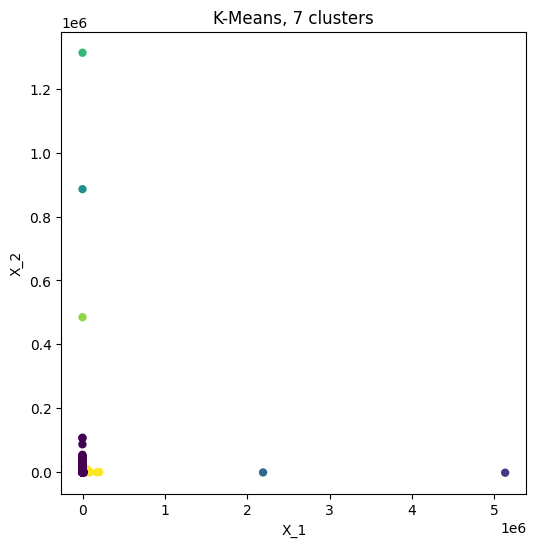

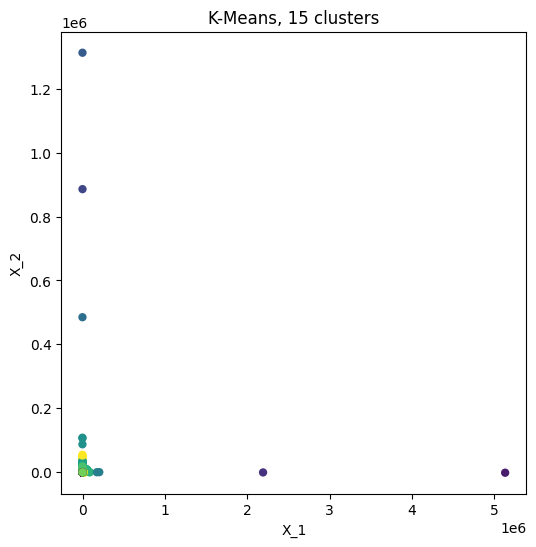

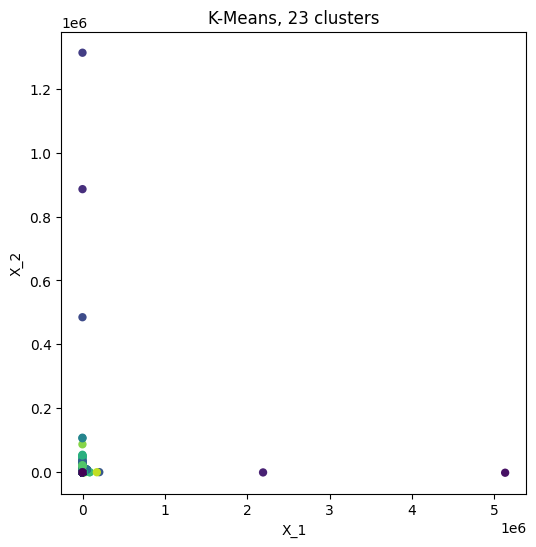

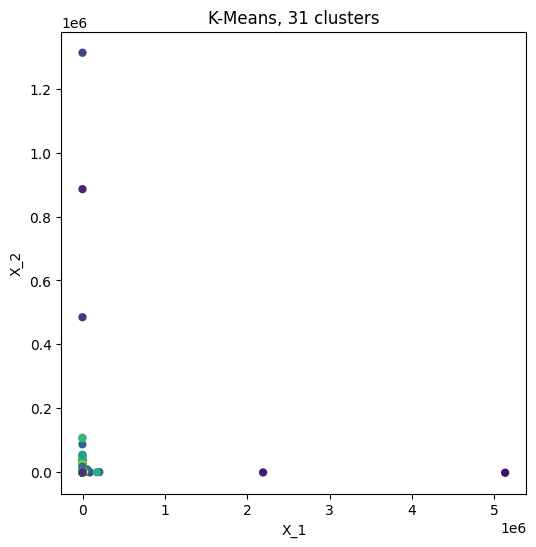

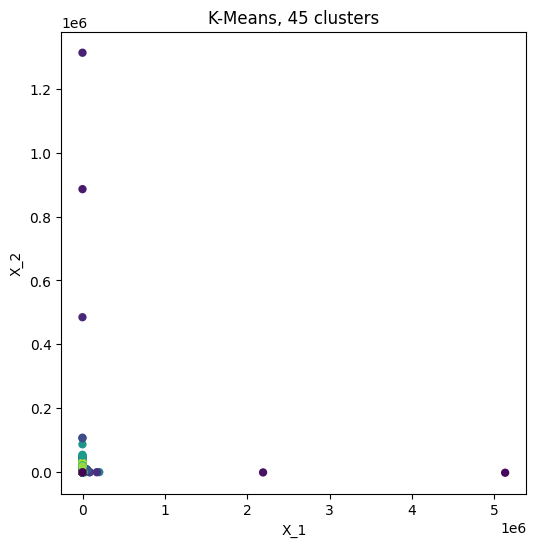

In [80]:
for k in [7, 15, 23, 31, 45]:
    display_plot(x_train2, km_results[k]['labels'], '2d', title=f"K-Means, {k} clusters")

### Spectral Clustering

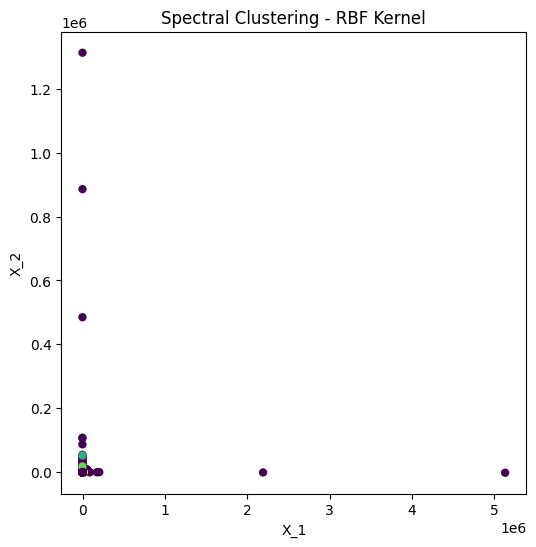

In [81]:
display_plot(x_train2, nc_labels, '2d', title="Spectral Clustering - RBF Kernel")

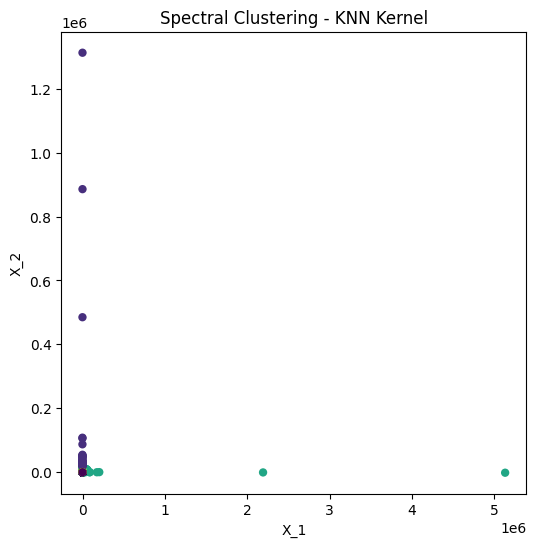

In [82]:
display_plot(x_train2, nc_labels_knn, '2d', title="Spectral Clustering - KNN Kernel")

### DBSCAN

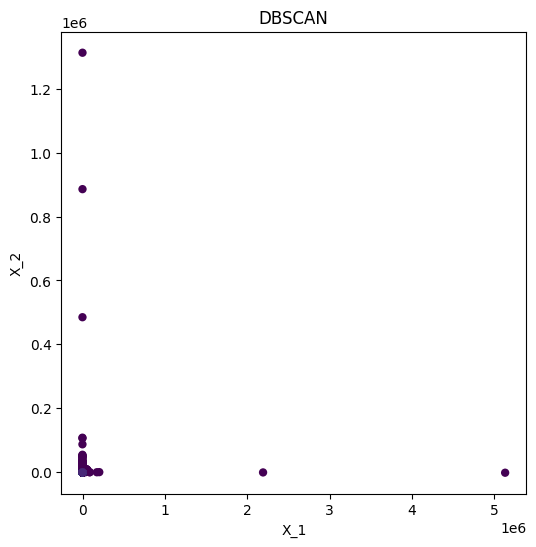

In [83]:
display_plot(x_train2, dbscan_labels, '2d', title=f"DBSCAN")